This dataset shows the annual library card registrations at Toronto Public Library branches.

A registration is defined as an individual initially signing up for a TPL card (it does not include card renewals).

Starting in 2020, individuals could register online for a digital access card (which provides access to TPL’s electronic resources), and these transactions are also included in the totals.

The VIR (Virtual Library) branch code is used to represent digital access card registrations.

In [1]:
import os
os.chdir("../")
cwd = os.getcwd()
print(cwd)

/home/ruchirich/Documents/repositories/toronto-open-data/tpl


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from utils.download_data import download_data
import math

In [3]:
pd.set_option('display.max_colwidth', 50)

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
params = { "id": "library-card-registrations"}
download_file = cwd+"/data/library-card-registrations.csv"

download_data(params, download_file)

In [6]:
# df = pd.read_csv(download_file, index_col='Timestamp', parse_dates=True, date_format="ISO8601", usecols=['Timestamp', 'Sales Count', 'Redemption Count'])
df = pd.read_csv(download_file)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   _id            1275 non-null   int64 
 1   Year           1275 non-null   int64 
 2   BranchCode     1275 non-null   object
 3   Registrations  1275 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 40.0+ KB


<Axes: xlabel='Year'>

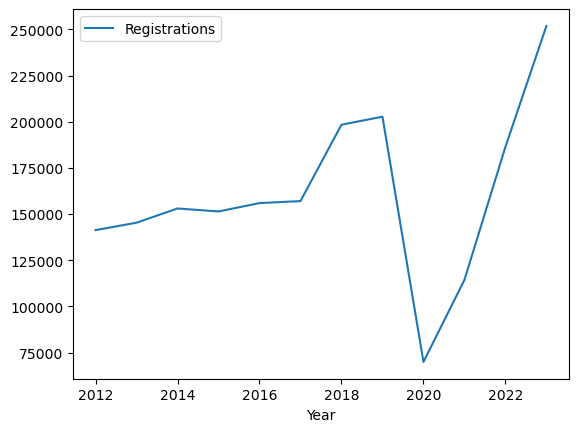

In [7]:
df[['Year', 'Registrations']].groupby('Year').sum().plot.line()